In [12]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns

from cellspec.utils.constants import MUTATION_TYPES, MUTATION_COLORS, get_canonical_96_order

PB   = Path("../results/worm6_final/DNA_analysis/pseudobulk_gatk")
POLE = Path("../results/worm6_final/DNA_analysis/pole_spectra")
FIG  = PB / "analyses" / "figures"
FIG.mkdir(exist_ok=True, parents=True)


# worm6 pseudobulk GATK — figures

Renders publication-style figures from `results/worm6_final/pseudobulk_gatk/` and `results/worm6_final/pole_spectra/`. Spectra use the K562 layout (6 panels, one per mutation class); per-worm distributions use the seaborn `histplot` layout from the worm QC notebooks.

In [20]:
colors = [
    '#FF1B5E',  # coral
    '#FFDB57',  # yellow
    '#438CFD',  # blue
    '#FF8C00',  # orange
    '#80F15E',  # lime green
    '#03FFFF',  # cyan
    '#5941A9',  # purple
    '#E980FC',  # magenta
    '#1A1A2E',  # navy
    '#F5F0FF',  # lavender white
    '#C17F3E',  # amber brown
]
extended_colors = [
    '#2E2A3A',
    '#FF8DAF', '#FF1B5E',
    '#FFEDA0', '#FFDB57',
    '#A4C8FE', '#438CFD',
    '#FFCF80', '#FF8C00',
    '#C4F9AE', '#80F15E',
    '#A0FFFF', '#03FFFF',
    '#A99FD4', '#5941A9',
    '#F4BFFE', '#E980FC',
    '#E8E4F0', '#C4BDD6',
    '#E8C89A', '#C17F3E'
]

In [9]:
import matplotlib.font_manager as fm
import os, glob


fm._load_fontmanager(try_read_cache=False)
# Register TeX Gyre Heros if present
for f in glob.glob(os.path.expanduser("~/.local/share/fonts/texgyreheros*.otf")):
    fm.fontManager.addfont(f)

In [10]:
mpl.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["TeX Gyre Heros"],
    "font.size": 12,

    "axes.linewidth": 2.5,
    # Tick marks
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,

    # Tick direction (outward is common in publications)
    "xtick.direction": "out",
    "ytick.direction": "out",
})

## Load pseudobulk outputs

In [13]:
summary = pd.read_csv(PB / "worm_summary.csv", index_col=0)
gt_counts = pd.read_csv(PB / "analyses" / "worm_genotype_counts.csv", index_col=0)
sharing = pd.read_csv(PB / "analyses" / "variant_sharing_counts.csv", index_col=0).squeeze("columns")

hom_spec = pd.read_csv(POLE / "spectra_matrix_hom.csv", index_col=0)
het_spec = pd.read_csv(POLE / "spectra_matrix_het.csv", index_col=0)

canon = get_canonical_96_order()
hom_spec = hom_spec.reindex(columns=canon, fill_value=0)
het_spec = het_spec.reindex(columns=canon, fill_value=0)

pooled = hom_spec.sum(axis=0) + het_spec.sum(axis=0)
grouped = pd.DataFrame({
    "hom":    hom_spec.sum(axis=0),
    "het":    het_spec.sum(axis=0),
    "pooled": pooled,
}).T[canon]

print(f"worms passing: {(summary['passes']).sum()} / {len(summary)}")
print(f"pooled spectrum n = {int(pooled.sum())} (hom {int(hom_spec.values.sum())} + het {int(het_spec.values.sum())})")
grouped.sum(axis=1)


worms passing: 16 / 20
pooled spectrum n = 20903 (hom 7441 + het 13462)


hom        7441
het       13462
pooled    20903
dtype: int64

## Pooled trinucleotide spectrum (K562 style)

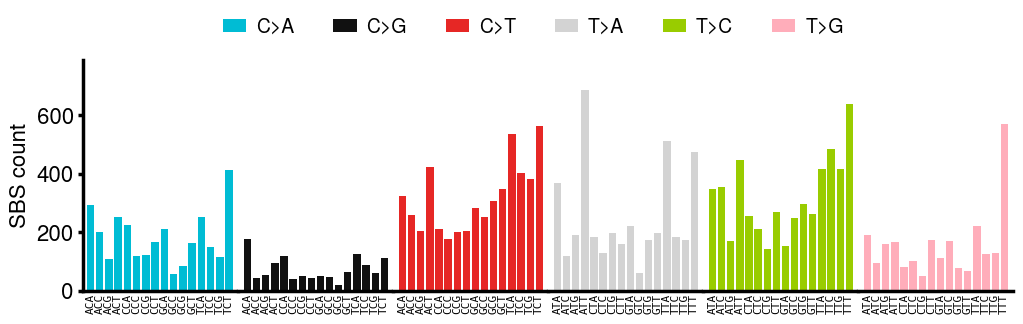

In [14]:
# --- knobs to tweak ---
figsize          = (12, 3)
bar_width        = 0.8
group_padding    = 0.5
wspace           = 0
left_pad         = 0.25
ylabel_fontsize  = 16
ytick_fontsize   = 16
xtick_fontsize   = 8
legend_fontsize  = 14
normalize        = False
ylim             = None       # auto — set to e.g. (0, 800) to fix
yticks           = None       # e.g. [0, 250, 500, 750]
colors_spec      = [MUTATION_COLORS[t] for t in MUTATION_TYPES]
# ----------------------

# for condition in ["pooled", "hom", "het"]:
spectrum = grouped.loc["pooled"].copy()
if normalize and spectrum.sum() > 0:
    spectrum = spectrum / spectrum.sum()

fig, axes = plt.subplots(1, 6, figsize=figsize, sharey=True)
y_min, y_max = ylim if ylim is not None else (0, spectrum.max() * 1.15)

for col, mut_type in enumerate(MUTATION_TYPES):
    ax = axes[col]
    contexts = [c for c in spectrum.index if f"{c[1]}>{c[5]}" == mut_type]
    counts   = [spectrum[c] for c in contexts]

    if col == 0:
        x_pos = np.arange(len(contexts)) + left_pad
        ax.set_xlim(-0.5, len(contexts) - 0.5 + left_pad + group_padding)
    else:
        x_pos = np.arange(len(contexts))
        ax.set_xlim(-0.5 - group_padding, len(contexts) - 0.5 + group_padding)
    ax.bar(x_pos, counts, color=colors_spec[col], width=bar_width, edgecolor="none")

    ax.set_ylim(y_min, y_max)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([c[:3] for c in contexts],
                       rotation=90, fontsize=xtick_fontsize,
                       family="monospace", ha="center", va="top")
    ax.tick_params(axis="x", length=0, pad=2)

    if col == 0:
        ax.tick_params(axis="y", labelsize=ytick_fontsize)
        ax.set_ylabel("SBS count" if not normalize else "SBS fraction",
                      fontsize=ylabel_fontsize)
        if yticks is not None:
            ax.set_yticks(yticks)
    else:
        ax.tick_params(axis="y", left=False, labelleft=False)
        ax.spines["left"].set_visible(False)

handles = [Patch(facecolor=MUTATION_COLORS[t], label=t) for t in MUTATION_TYPES]
fig.legend(handles=handles, ncol=6, frameon=False,
           loc="lower center", bbox_to_anchor=(0.5, 0.9),
           fontsize=legend_fontsize, handlelength=1.2,
           columnspacing=2.0, handletextpad=0.5)

plt.subplots_adjust(wspace=wspace)
# fig.suptitle(f"pooled worm6 spectrum — {condition}   n={int(spectrum.sum())}",
#              y=1.15, fontsize=13)
plt.savefig("../results/worm6_final/figures/pseudobulk_spectrum.png",
            dpi=600, bbox_inches="tight")
plt.show()


## Variant sharing across worms

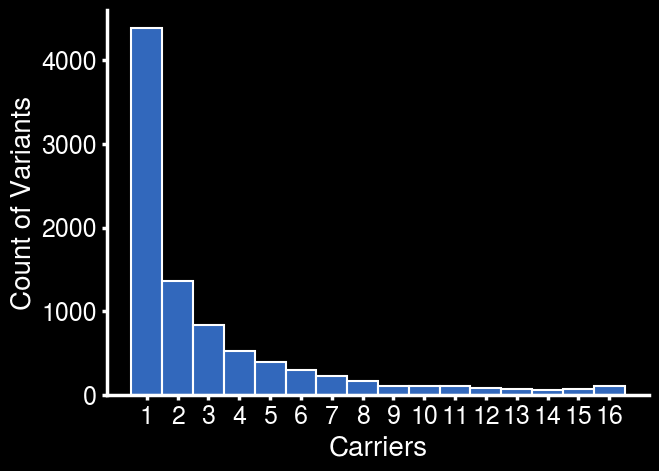

In [21]:
# sharing['n_worms'] -> n_variants; expand to a per-variant Series so histplot bins it
per_variant_n = sharing.reindex(range(1, 17), fill_value=0)
long = per_variant_n.reset_index()
long.columns = ["n_worms", "n_variants"]
expanded = long.loc[long.index.repeat(long["n_variants"]), "n_worms"].reset_index(drop=True)

f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(expanded,
             alpha=0.75,
             color=colors[2],
             linewidth=1.5,
             ax=ax,
             bins=np.arange(0.5, 17.5, 1),
             discrete=True)
plt.xlabel("Carriers", fontsize=20)
plt.ylabel("Count of Variants", fontsize=20)
ax.set_xticks(range(1, 17))
ax.tick_params(labelsize=18)
plt.savefig("../results/worm6_final/figures/variant_sharing_histogram.png", dpi=600, bbox_inches="tight")
plt.show()


# Dark figures

In [16]:
import matplotlib.ticker as mticker
from cellspec.utils.constants import MUTATION_TYPES, MUTATION_COLORS, MUTATION_COLORS_DARK


In [17]:
plt.style.use("dark_background")

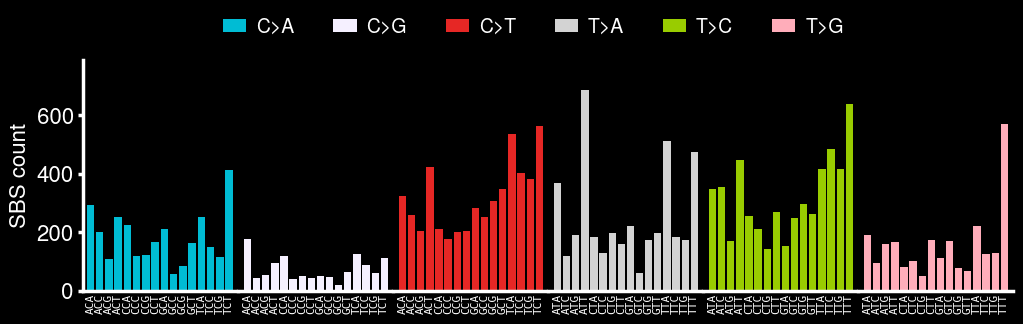

In [26]:
# --- knobs to tweak ---
figsize          = (12, 3)
bar_width        = 0.8
group_padding    = 0.5
wspace           = 0
left_pad         = 0.25
ylabel_fontsize  = 16
ytick_fontsize   = 16
xtick_fontsize   = 8
legend_fontsize  = 14
normalize        = False
ylim             = None       # auto — set to e.g. (0, 800) to fix
yticks           = None       # e.g. [0, 250, 500, 750]
colors_spec = [MUTATION_COLORS_DARK[t] for t in MUTATION_TYPES]
# ----------------------

# for condition in ["pooled", "hom", "het"]:
spectrum = grouped.loc["pooled"].copy()
if normalize and spectrum.sum() > 0:
    spectrum = spectrum / spectrum.sum()

fig, axes = plt.subplots(1, 6, figsize=figsize, sharey=True)
y_min, y_max = ylim if ylim is not None else (0, spectrum.max() * 1.15)

for col, mut_type in enumerate(MUTATION_TYPES):
    ax = axes[col]
    contexts = [c for c in spectrum.index if f"{c[1]}>{c[5]}" == mut_type]
    counts   = [spectrum[c] for c in contexts]

    if col == 0:
        x_pos = np.arange(len(contexts)) + left_pad
        ax.set_xlim(-0.5, len(contexts) - 0.5 + left_pad + group_padding)
    else:
        x_pos = np.arange(len(contexts))
        ax.set_xlim(-0.5 - group_padding, len(contexts) - 0.5 + group_padding)
    ax.bar(x_pos, counts, color=colors_spec[col], width=bar_width, edgecolor="none")

    ax.set_ylim(y_min, y_max)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([c[:3] for c in contexts],
                       rotation=90, fontsize=xtick_fontsize,
                       family="monospace", ha="center", va="top")
    ax.tick_params(axis="x", length=0, pad=2)

    if col == 0:
        ax.tick_params(axis="y", labelsize=ytick_fontsize)
        ax.set_ylabel("SBS count" if not normalize else "SBS fraction",
                      fontsize=ylabel_fontsize)
        if yticks is not None:
            ax.set_yticks(yticks)
    else:
        ax.tick_params(axis="y", left=False, labelleft=False)
        ax.spines["left"].set_visible(False)

handles = [Patch(facecolor=MUTATION_COLORS_DARK[t], label=t) for t in MUTATION_TYPES]
fig.legend(handles=handles, ncol=6, frameon=False,
           loc="lower center", bbox_to_anchor=(0.5, 0.9),
           fontsize=legend_fontsize, handlelength=1.2,
           columnspacing=2.0, handletextpad=0.5)

plt.subplots_adjust(wspace=wspace)
# fig.suptitle(f"pooled worm6 spectrum — {condition}   n={int(spectrum.sum())}",
#              y=1.15, fontsize=13)
plt.savefig("../../presentation_figures/worm06/pseudobulk_spectrum.png",
            dpi=600, bbox_inches="tight", transparent=True)
plt.show()


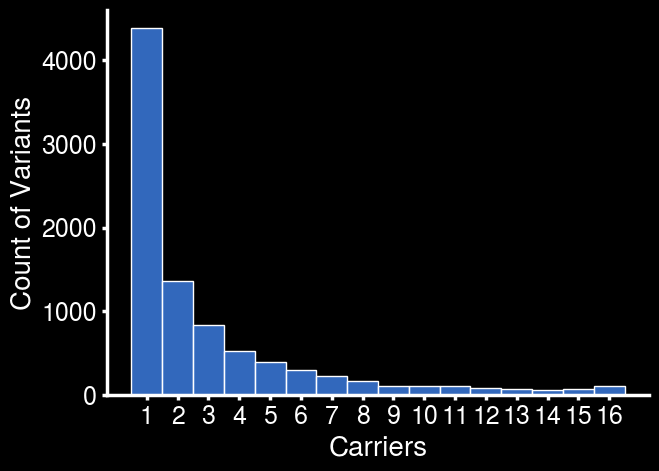

In [25]:
# sharing['n_worms'] -> n_variants; expand to a per-variant Series so histplot bins it
per_variant_n = sharing.reindex(range(1, 17), fill_value=0)
long = per_variant_n.reset_index()
long.columns = ["n_worms", "n_variants"]
expanded = long.loc[long.index.repeat(long["n_variants"]), "n_worms"].reset_index(drop=True)

f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(expanded,
             alpha=0.75,
             color=colors[2],
             linewidth=1,
             ax=ax,
             bins=np.arange(0.5, 17.5, 1),
             discrete=True)
plt.xlabel("Carriers", fontsize=20)
plt.ylabel("Count of Variants", fontsize=20)
ax.set_xticks(range(1, 17))
ax.tick_params(labelsize=18)
plt.savefig("../../presentation_figures/worm06/variant_sharing_histogram.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()
